Heart Disease Prediction

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_curve, roc_auc_score)
import kagglehub

# 1. Download and load dataset
path = kagglehub.dataset_download("hamnawaseem112222222/uci-heart-disease-dataset")
print("Path to dataset files:", path)

df = pd.read_csv(path + "/heart_disease_combined.csv")
print(df.shape)
print(df.head())
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
df = df.dropna()

Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\hamnawaseem112222222\uci-heart-disease-dataset\versions\1
(920, 15)
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target     source  
0    3.0  0.0   6.0       0  cleveland  
1    2.0  3.0   3.0       1  cleveland  
2    2.0  2.0   7.0       1  cleveland  
3    3.0  0.0   3.0       0  cleveland  
4    1.0  0.0   3.0       0  cleveland  

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'source']

Missing values:


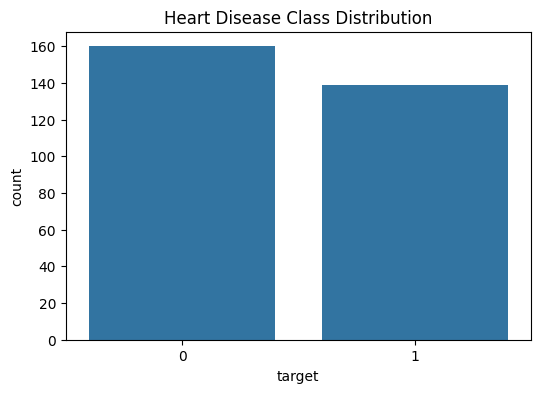

In [16]:
# 2. EDA — class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df)
plt.title("Heart Disease Class Distribution")
plt.show()

In [17]:
df = df.rename(columns={"num": "target"})
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)  # only needed if values go 0-4

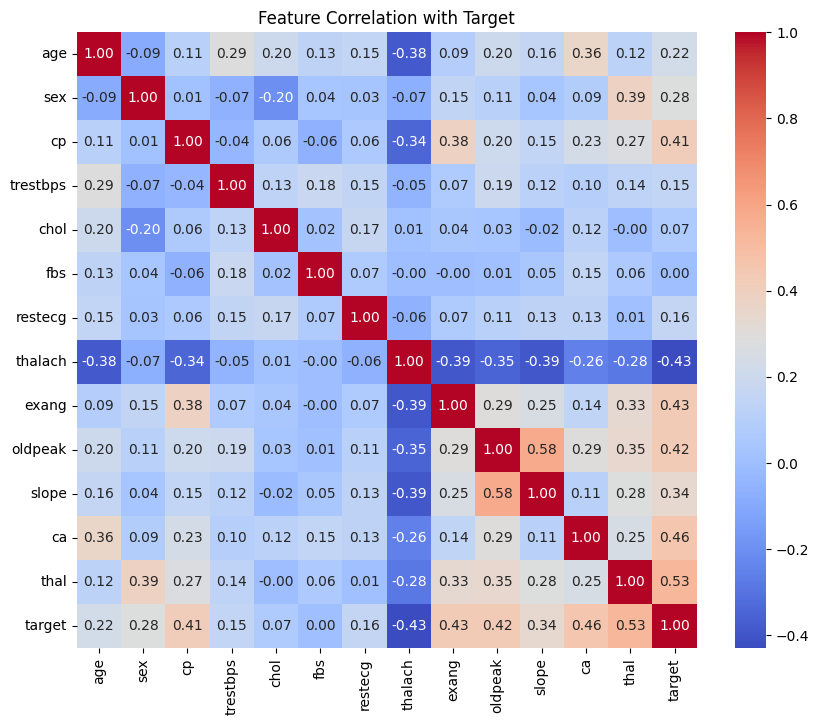

In [18]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation with Target")
plt.show()

In [25]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
# 6. Train Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
log_preds = log_model.predict(X_test_scaled)

# 7. Train Decision Tree
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
tree_preds = tree_model.predict(X_test)

In [27]:
# 8. Evaluate both models
for name, preds in [("Logistic Regression", log_preds), ("Decision Tree", tree_preds)]:
    print(f"\n--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
    print("Classification Report:\n", classification_report(y_test, preds))


--- Logistic Regression ---
Accuracy: 0.8166666666666667
Confusion Matrix:
 [[28  4]
 [ 7 21]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.88      0.84        32
           1       0.84      0.75      0.79        28

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.81        60
weighted avg       0.82      0.82      0.82        60


--- Decision Tree ---
Accuracy: 0.75
Confusion Matrix:
 [[28  4]
 [11 17]]
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.88      0.79        32
           1       0.81      0.61      0.69        28

    accuracy                           0.75        60
   macro avg       0.76      0.74      0.74        60
weighted avg       0.76      0.75      0.74        60



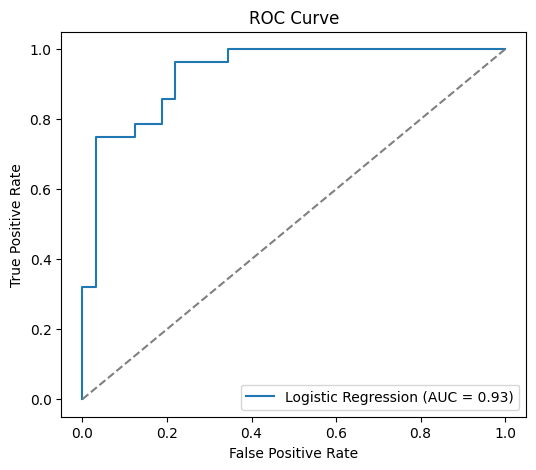

In [28]:
# 9. ROC Curve
y_proba = log_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

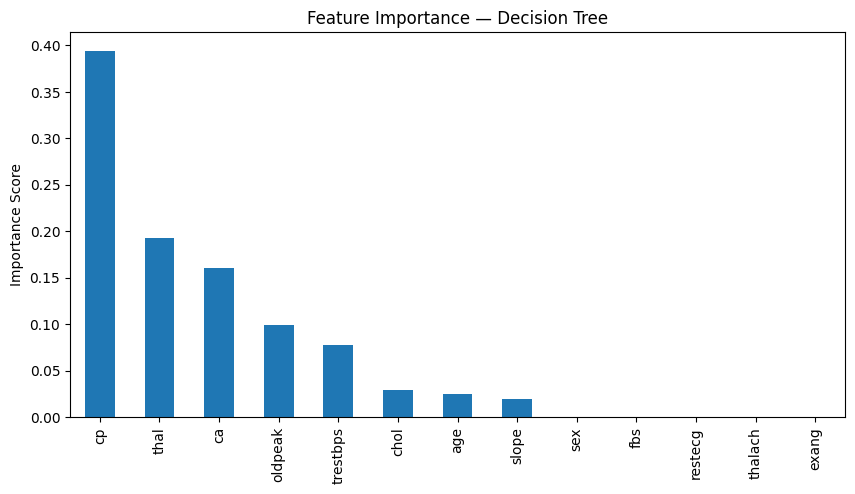

In [29]:
# 10. Feature importance
importance = pd.Series(tree_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind="bar", figsize=(10, 5))
plt.title("Feature Importance — Decision Tree")
plt.ylabel("Importance Score")
plt.show()